# Unrolling π: A Practical Exercise in Approximation, Error, and Insight 
Pi Day: 03/14 of each year

This tutorial keeps your original exercise but clarifies the math, fixes code, improves performance options, and explains what the experiment teaches about sampling, convergence, and numerical practice. 

---
### Sumudu Tennakoon, PhD
#### **www.datasciencefoundations.com**
---

## 1. Gregory-Leibniz Series

The Gregory series is a pi formula found by Gregory and Leibniz and obtained by plugging into the Leibniz series.  It is simple and instructive, but converges very slowly. Use it as a laboratory for numerical thinking, then compare it to faster formulas and vectorized/parallel implementations.

Read more: 
* http://mathworld.wolfram.com/GregorySeries.html
* http://mathworld.wolfram.com/Pi.html
* http://mathworld.wolfram.com/PiFormulas.html


he Gregory–Leibniz series for π is the alternating series
$$
\pi \;=\; S_{\infty} \;=\; 4\sum_{n=1}^{\infty}\frac{(-1)^{\,n+1}}{2n-1},
$$

The \(N\)-term partial sum is
$$
S_N \;=\; 4\sum_{n=1}^{N}\frac{(-1)^{\,n+1}}{2n-1},
$$

Given 
$$
a_{n} \;=\; \frac{4}{2n-1},
$$
Because the series is alternating with monotonically decreasing term magnitudes, the remainder 
$$
|R_N| \;=\; |S_{\infty}-S_{\N}| \le a_{N} \;=\; \frac{4}{2(N+1)-1},\\
$$

This satisfies the alternating series error bound:
$$
\varepsilon \;=\; |R_N| \;=\;  |S_{\infty}-S_{\N}| \le \frac{4}{2N+1},
$$

Asymptotically, the error decays like
$$
\varepsilon \sim \frac{2}{N},
$$
Where N is number of terms in the series. 

To compute the value of N needed to achive 𝜀 = 1E-6
$$
\frac{4}{2N+1} < 10^{-6}
\quad\Longrightarrow\quad
2N+1 > 4\times 10^{6}
\quad\Longrightarrow\quad
N > \frac{4\times 10^{6}-1}{2}.
$$

Thus,
$$
N \approx 2{,}000{,}000.
$$


This shows us the Gregory–Leibniz series converges very slowly — a useful pedagogical example for studying **error bounds**, **convergence rates**, and **numerical summation**.

### 1.1 Use Sympy to generate Equation

In [20]:
from sympy import symbols, Eq, S, Sum, oo, init_printing
n  = symbols('n', integer=True)
init_printing()

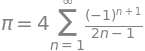

In [21]:
Eq(S.Pi, 4 * Sum(( ( (-1)**(n+1) ) / (2*n-1)), (n,1,oo)))

In [22]:
from timeit import default_timer as timer
import numpy as np

### 1.2 Function to Compute Pi (π)

### 1.2.1 Serial Processering

In [ ]:
def CalculatePi_Serial(N): # Do not recomend to use with larget N values
    start = timer()
    pi = 0
    for n in range(1, N):
        pi += (4.0 * ( (-1)**(n+1) ) / (2*n-1) ) 
    dt = timer() - start
    print('Serial Compute Time {:e} s'.format(dt))
    return pi

In [25]:
N =1000000
PI = CalculatePi_Serial(N)
difference = PI-np.pi
print('  N = {}'.format(N))
print('* Gregory-Leibniz Series = {}'.format(PI))
print('* Pi value in Numpy      = {}'.format(np.pi))
print('* Difference             = {:e}'.format(difference))
print('* % Difference           = {:%}'.format(difference/np.pi))

Serial calculate time   3.047275e-01 s
  N = 1000000
* Gregory-Leibniz Series = 3.1415936535907742
* Pi value in Numpy      = 3.141592653589793
* Difference             = 1.000001e-06
* % Difference           = 0.000032%


### 1.2.2 Vectorized Function

In [ ]:
def CalculatePi_Vectorized(N):
    start = timer()

    n = np.arange(1, N, dtype=np.float64)
    pi = np.sum(4.0 * ((-1.0)**(n+1)) / (2*n - 1))

    dt = timer() - start
    print('Vectorized Compute Time {:e} s'.format(dt))
    return pi

In [27]:
N =1000000
PI = CalculatePi_Vectorized(N)
difference = PI-np.pi
print('  N = {}'.format(N))
print('* Gregory-Leibniz Series = {}'.format(PI))
print('* Pi value in Numpy      = {}'.format(np.pi))
print('* Difference             = {:e}'.format(difference))
print('* % Difference           = {:%}'.format(difference/np.pi))

Vectorized calculate time 3.850320e-02 s
  N = 1000000
* Gregory-Leibniz Series = 3.141593653590794
* Pi value in Numpy      = 3.141592653589793
* Difference             = 1.000001e-06
* % Difference           = 0.000032%


### 1.2.3 Parallel Processering with Numba (multi‑core)

##### Using Numba (https://numba.pydata.org/)
```bash
# If you use pip
pip install numba

# If you use conda
conda install numba
```

* Numba will JIT‑compile your Python loops into fast machine code.
* The first call compiles the function (slower).
* All later calls are extremely fast.

In [ ]:
from numba import njit, prange
from timeit import default_timer as timer
import numpy as np

@njit(parallel=True)
def _CalculatePi_NumbaParallel_inner(N):
    pi = 0.0
    for n in prange(1, N):
        pi += (4.0 * ((-1)**(n+1)) / (2*n - 1))
    return pi

def CalculatePi_NumbaParallel(N):
    start = timer()
    pi = _CalculatePi_NumbaParallel_inner(N)
    dt = timer() - start
    print('NumbaParallel Compute Time {:e} s'.format(dt))
    return pi

In [29]:
N =1000000
PI = CalculatePi_NumbaParallel(N)
difference = PI-np.pi
print('  N = {}'.format(N))
print('* Gregory-Leibniz Series = {}'.format(PI))
print('* Pi value in Numpy      = {}'.format(np.pi))
print('* Difference             = {:e}'.format(difference))
print('* % Difference           = {:%}'.format(difference/np.pi))

Parallel calculate time 3.087612e-01 s
  N = 1000000
* Gregory-Leibniz Series = 3.14159365359078
* Pi value in Numpy      = 3.141592653589793
* Difference             = 1.000001e-06
* % Difference           = 0.000032%


## 1.3 Run time performance Parallel vs. Serial 

In [ ]:
N =1000000
PI_S = CalculatePi_Serial(N)
PI_V = CalculatePi_Vectorized(N)
PI_NP = CalculatePi_NumbaParallel(N)

Serial calculate time   3.151725e-01 s
Vectorized calculate time 3.569180e-02 s
Parallel calculate time 2.177200e-03 s


## 1.4 Comparing Accuract vs. N

In [ ]:
N = np.array([10, 25, 50, 100, 500, 1000, 5000, 10000, 100000, 1000000, 10000000, 100000000, 1000000000])
PI = []
for n in N:
    PI.append(CalculatePi_NumbaParallel(n))
PI = np.array(PI)
NumpyPI = np.pi
Difference = (PI-NumpyPI)/NumpyPI

Parallel calculate time 1.554000e-04 s
Parallel calculate time 5.190005e-05 s
Parallel calculate time 2.063999e-04 s
Parallel calculate time 2.169000e-04 s
Parallel calculate time 2.420000e-04 s
Parallel calculate time 1.060000e-04 s
Parallel calculate time 3.279999e-04 s
Parallel calculate time 1.068000e-04 s
Parallel calculate time 8.400000e-04 s
Parallel calculate time 3.160900e-03 s
Parallel calculate time 2.340110e-02 s
Parallel calculate time 1.704796e-01 s
Parallel calculate time 1.629338e+00 s


In [52]:
Difference = abs(PI-NumpyPI)/NumpyPI
for i in range(len(N)):
    print('* Pi [N = {:18}] = {:.36} ({:.8%})'.format(N[i], PI[i], Difference[i]))
print('* Pi [Numpy]                  = {:.36}'.format(np.pi))

* Pi [N =                 10] = 3.25236593471887669437592194299213588 (3.52602305%)
* Pi [N =                 25] = 3.09994403237380700133485333935823292 (1.32571679%)
* Pi [N =                 50] = 3.161998692995051207788037572754547 (0.64954441%)
* Pi [N =                100] = 3.1516934060711170317858886846806854 (0.32151694%)
* Pi [N =                500] = 3.14359665959378853372641060559544712 (0.06378949%)
* Pi [N =               1000] = 3.14259365434004322992223023902624846 (0.03186284%)
* Pi [N =               5000] = 3.14179269359579249609737416903953999 (0.00636747%)
* Pi [N =              10000] = 3.14169266359054333292988303583115339 (0.00318342%)
* Pi [N =             100000] = 3.14160265368979185751641125534661114 (0.00031831%)
* Pi [N =            1000000] = 3.14159365359078002200021728640422225 (0.00003183%)
* Pi [N =           10000000] = 3.14159275358970280223047666368074715 (0.00000318%)
* Pi [N =          100000000] = 3.14159266358977928845774840738158673 (0.000000

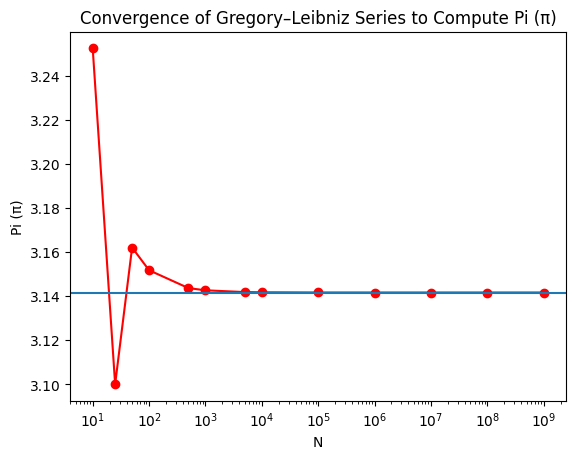

In [63]:
import matplotlib.pyplot as plt
plt.plot(N, PI, "r-o")
plt.axhline(np.pi)
plt.xscale('log')
plt.xlabel('N')
plt.ylabel('Pi (π)')
plt.title("Convergence of Gregory–Leibniz Series to Compute Pi (π)")
plt.show()

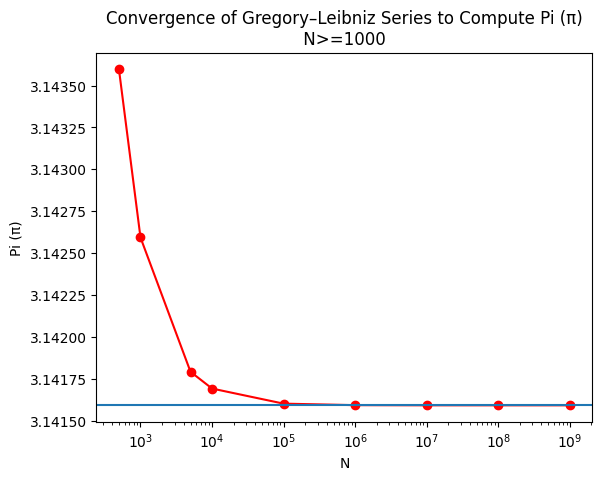

In [64]:
plt.plot(N[4:], PI[4:], "r-o")
plt.axhline(np.pi)
plt.xscale('log')
plt.xlabel('N')
plt.ylabel('Pi (π)')
plt.title("Convergence of Gregory–Leibniz Series to Compute Pi (π)\n N>=1000 ")
plt.show()

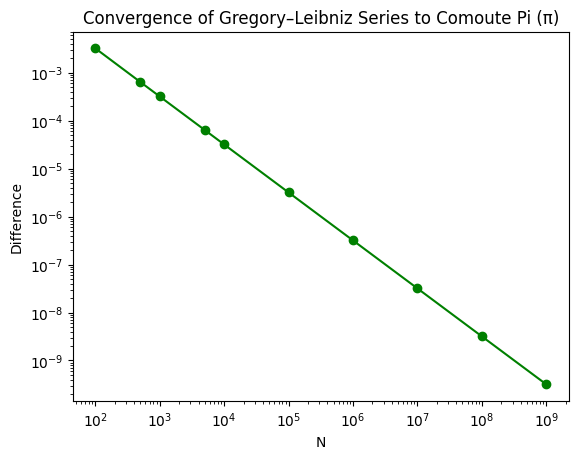

In [65]:
plt.plot(N[3:], Difference[3:], "g-o")
plt.axhline(0)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Difference')
plt.title("Convergence of Gregory–Leibniz Series to Comoute Pi (π)")
plt.show()

## 2. Monte Carlo Estimation

##### The Problem: 
Estimate the value of π by measuring the area of a circle inscribed into a square.

##### Solution Approach: 
Simulate probing a large number of random points on the x,y plane within the square's perimeter with a side of 2 units. Determine how many of them within the inscribed circle with radius = 1 unit. 

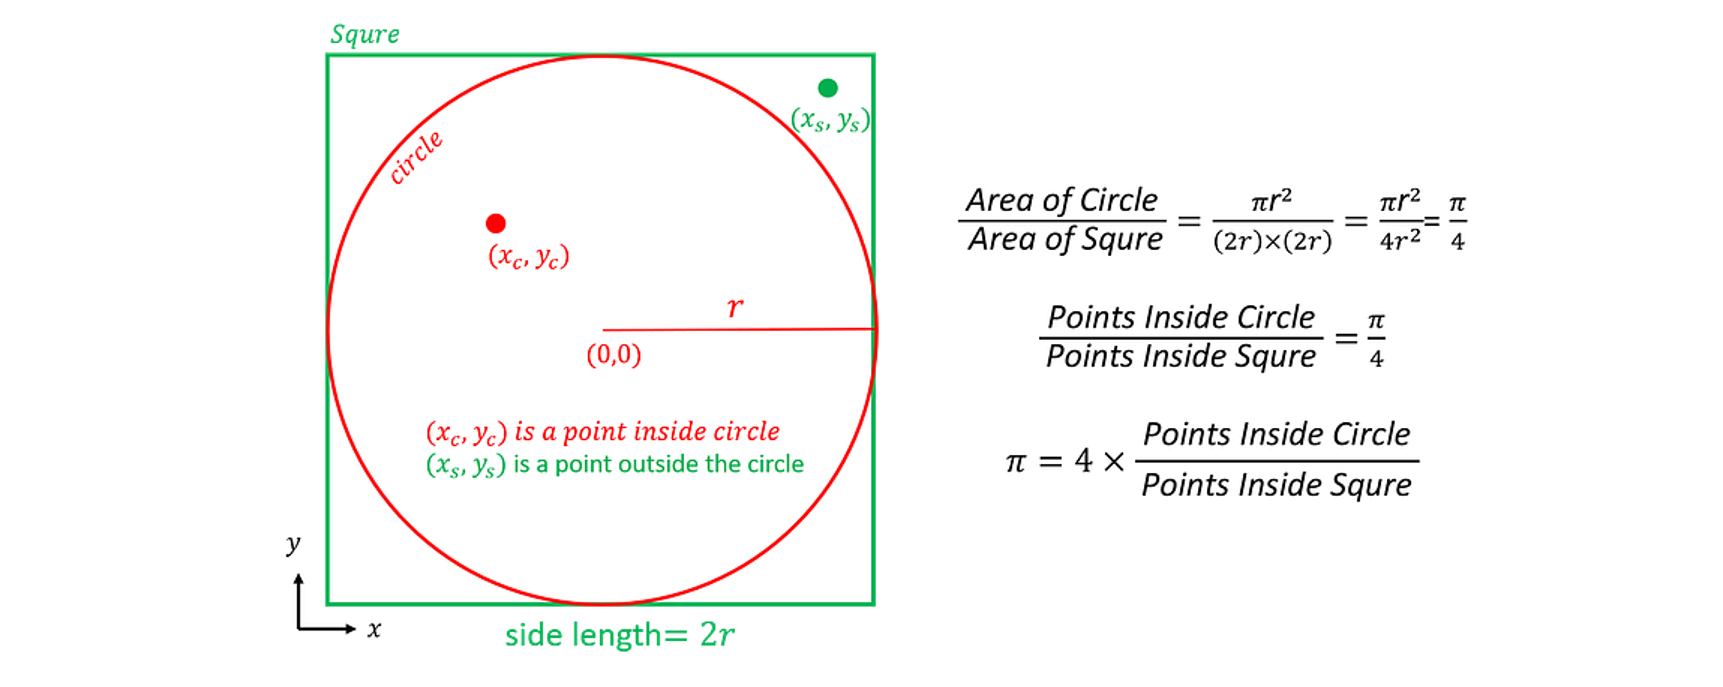

random number generator

In [93]:
import numpy as np
import time

def CalculatePi_MonteCarlo(N, return_points=False):
    start = time.perf_counter()
    x = np.random.uniform(-1, 1, N)
    y = np.random.uniform(-1, 1, N)
    R = x**2 + y**2
    is_inside = (R <= 1.0)
    inside = np.count_nonzero(is_inside)
    pi = 4.0 * inside / N
    dt = time.perf_counter() - start
    print(f'[N = {N}] MonteCarlo Compute Time {dt:e} s')

    if return_points:
        return pi, x, y, is_inside
    else:
        return pi

pi = CalculatePi_MonteCarlo(N=10000)
print("MC pi:", pi)


[N = 10000] MonteCarlo Compute Time 2.563000e-04 s
MC pi: 3.136


[N = 10000] MonteCarlo Compute Time 1.949001e-04 s
MC pi: 3.16


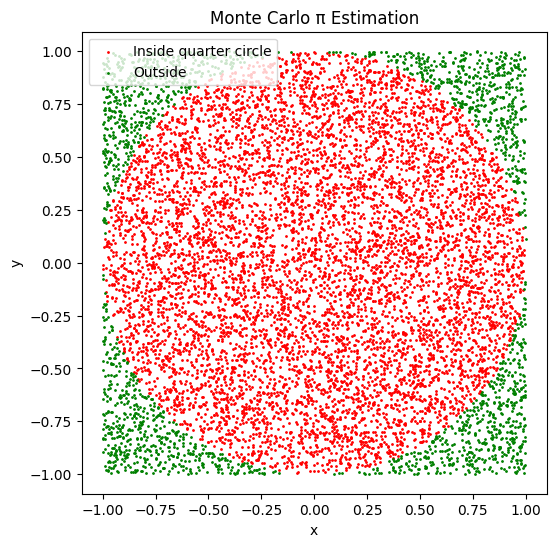

In [94]:
pi, x, y, is_inside = CalculatePi_MonteCarlo(10000, return_points=True)
print("MC pi:", pi)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(x[is_inside], y[is_inside], s=1, color='red', label='Inside quarter circle')
plt.scatter(x[~is_inside], y[~is_inside], s=1, color='green', label='Outside')
plt.title("Monte Carlo π Estimation")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")
plt.show()

In [95]:
pi = CalculatePi_MonteCarlo(N=100000)
print("MC pi:", pi)

[N = 100000] MonteCarlo Compute Time 2.385600e-03 s
MC pi: 3.1464


[N = 100] MonteCarlo Compute Time 8.360005e-05 s
[N = 183] MonteCarlo Compute Time 1.406000e-04 s
[N = 335] MonteCarlo Compute Time 5.592001e-04 s
[N = 615] MonteCarlo Compute Time 9.570003e-05 s
[N = 1128] MonteCarlo Compute Time 1.230000e-04 s
[N = 2069] MonteCarlo Compute Time 2.355000e-04 s
[N = 3792] MonteCarlo Compute Time 1.375000e-04 s
[N = 6951] MonteCarlo Compute Time 2.002000e-04 s
[N = 12742] MonteCarlo Compute Time 2.600000e-04 s
[N = 23357] MonteCarlo Compute Time 4.843000e-04 s
[N = 42813] MonteCarlo Compute Time 1.421100e-03 s
[N = 78475] MonteCarlo Compute Time 2.221300e-03 s
[N = 143844] MonteCarlo Compute Time 4.528000e-03 s
[N = 263665] MonteCarlo Compute Time 8.326400e-03 s
[N = 483293] MonteCarlo Compute Time 1.559340e-02 s
[N = 885866] MonteCarlo Compute Time 2.192750e-02 s
[N = 1623776] MonteCarlo Compute Time 3.451440e-02 s
[N = 2976351] MonteCarlo Compute Time 7.380880e-02 s
[N = 5455594] MonteCarlo Compute Time 1.221956e-01 s
[N = 10000000] MonteCarlo Compute

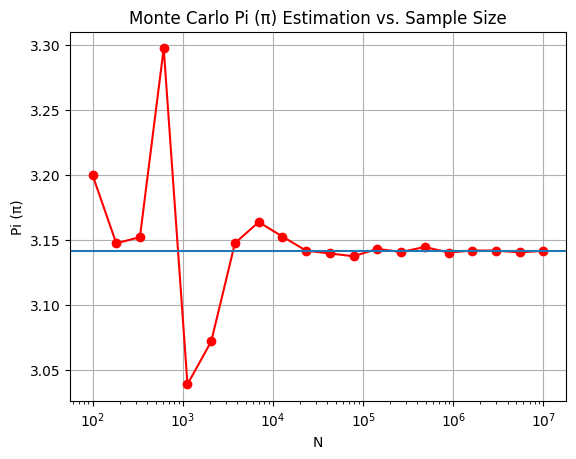

In [106]:
N_s = np.logspace(2, 7, 20, dtype=int)
pi_s = []

for N in N_s:
    pi_s.append(CalculatePi_MonteCarlo(N))

pi_s = np.array(pi_s)

plt.plot(N_s, pi_s, "o-r")
plt.axhline(np.pi)
plt.xscale('log')
plt.xlabel("N")
plt.ylabel("Pi (π)")
plt.title("Monte Carlo Pi (π) Estimation vs. Sample Size")
plt.grid(True)
plt.show()

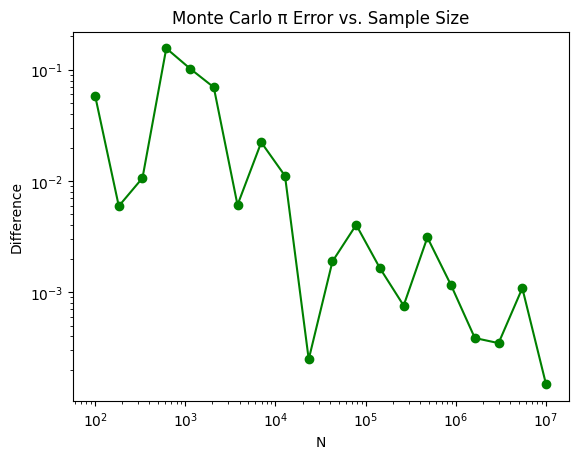

In [110]:
plt.plot(N_s, abs(np.pi-pi_s), "g-o")
plt.axhline(0)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Difference')
plt.title("Monte Carlo π Error vs. Sample Size")
plt.show()

---
**Attribution:** 
This tutorial includes AI‑assisted text and Python code generated with [Microsoft Copilot](https://copilot.microsoft.com), based on initial ideas developed by the author with step by step interactions with the AI tool in refining the content. All content was reviewed and edited before publication.

First Upload [2018-06-30](https://github.com/SumuduTennakoon/ComputingIsFun/commit/c752503611cb834cb5728671f1adbfca7b5c30ff) | Last update 2026-03-14 by Sumudu Tennakoon

<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-sa/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License</a>.